# Freight Rate Prediction — Model Benchmarking

**Objective**: Train and benchmark 3 model families on engineered features. Select the champion model and generate all submission artifacts.

| Phase | Action |
|---|---|
| **Baseline** | Ridge Regression (linear floor) |
| **Intermediate** | Random Forest Regressor |
| **Champion** | LightGBM Regressor / Random Forest |
| **Outputs** | `validation_predictions.csv`, `december-chart-inputs.csv` (filled), run `score.py` |

In [ ]:
# Cell 1: Imports & Setup
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

SEED = 42
np.random.seed(SEED)
print("Setup complete.")

In [ ]:
# Cell 2: Load Engineered Datasets
def find_processed(filename):
    candidates = [
        os.path.join("data", "processed", filename),
        os.path.join("..", "data", "processed", filename),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(filename)

train_df = pd.read_csv(find_processed("engineered_train_full.csv"), parse_dates=["date"])
val_df   = pd.read_csv(find_processed("engineered_validation_test.csv"), parse_dates=["date"])
dec_df   = pd.read_csv(find_processed("engineered_december_scenario.csv"), parse_dates=["date"])

print(f"Train:      {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"December:   {dec_df.shape}")

In [ ]:
# Cell 3: Define Feature Columns & OOT Split
FEATURE_COLS = [
    "distance", "log_distance", "weight", "log_weight", "weight_ton", "ton_miles",
    "market_index", "quote_signal", "quote_deviation", "quote_is_urgent", "quote_is_distressed",
    "is_short_haul", "is_long_haul", "market_quote_interaction",
    "haversine_dist", "detour_ratio", "lane_rpm_enc",
    "day_of_week", "is_weekend", "month", "day_of_year", "week_of_year",
    "dow_sin", "dow_cos", "month_sin", "month_cos", "doy_sin", "doy_cos",
    "eq_Dry Van", "eq_Flatbed", "eq_Reefer"
]
TARGET = "posted_rate"

# OOT Split: Jan-Sep 2025 = train, Oct 2025 = local holdout
split_date = pd.to_datetime("2025-10-01")
oot_train_mask = train_df["date"] < split_date
oot_val_mask   = train_df["date"] >= split_date

# Defensive NaN filling (using training medians) to ensure sklearn models never see NaNs
train_medians = train_df.loc[oot_train_mask, FEATURE_COLS].median()
train_df[FEATURE_COLS] = train_df[FEATURE_COLS].fillna(train_medians)
val_df[FEATURE_COLS]   = val_df[FEATURE_COLS].fillna(train_medians)
dec_df[FEATURE_COLS]   = dec_df[FEATURE_COLS].fillna(train_medians)

X_train = train_df.loc[oot_train_mask, FEATURE_COLS]
y_train = train_df.loc[oot_train_mask, TARGET]
X_oot   = train_df.loc[oot_val_mask,   FEATURE_COLS]
y_oot   = train_df.loc[oot_val_mask,   TARGET]

print(f"OOT Train:    X={X_train.shape}, y={y_train.shape} | NaNs={X_train.isnull().sum().sum()}")
print(f"OOT Holdout:  X={X_oot.shape},   y={y_oot.shape}   | NaNs={X_oot.isnull().sum().sum()}")

In [ ]:
# Cell 4: Evaluation Helper Function
results = {}  # Store all model metrics

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "MAPE%": mape, "R2": r2}
    print(f"[{name}]")
    print(f"  MAE   = ${mae:,.2f}")
    print(f"  RMSE  = ${rmse:,.2f}")
    print(f"  MAPE  = {mape:.2f}%")
    print(f"  R²    = {r2:.4f}")
    print()

print("Evaluation helper ready.")

In [ ]:
# Cell 5: Model 1 — Ridge Regression (Linear Baseline)
# Ridge adds L2 regularization to prevent overfitting on correlated features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_oot_sc   = scaler.transform(X_oot)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
ridge_preds = ridge.predict(X_oot_sc)
ridge_preds = np.clip(ridge_preds, 1.0, None)  # Ensure no negative predictions

evaluate("Ridge (Baseline)", y_oot, ridge_preds)

In [ ]:
# Cell 6: Model 2 — Random Forest Regressor
# Captures non-linear interactions; robust ensemble of bagging decision trees
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    min_samples_leaf=4,
    max_features=0.6,
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_oot)
rf_preds = np.clip(rf_preds, 1.0, None)

evaluate("Random Forest", y_oot, rf_preds)

In [ ]:
# Cell 7: Model 3 — LightGBM Regressor
# Gradient Boosted Trees: fast, handles non-linearity, learns feature interactions
lgb_params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 127,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "n_estimators": 1500,
    "random_state": SEED,
    "verbose": -1
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_oot, y_oot)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
               lgb.log_evaluation(period=200)]
)
lgb_preds = lgb_model.predict(X_oot)
lgb_preds = np.clip(lgb_preds, 1.0, None)

evaluate("LightGBM", y_oot, lgb_preds)

In [ ]:
# Cell 8: Model Comparison Table & Champion Selection
comparison_df = pd.DataFrame(results).T.reset_index()
comparison_df.columns = ["Model", "MAE ($)", "RMSE ($)", "MAPE (%)", "R²"]
comparison_df = comparison_df.sort_values("MAE ($)")

print("\n=== MODEL COMPARISON (OOT October 2025 Holdout) ===")
display(comparison_df)

champion_name = comparison_df.iloc[0]["Model"]
print(f"\n>>> CHAMPION MODEL SELECTED: {champion_name} (Lowest MAE) <<<")

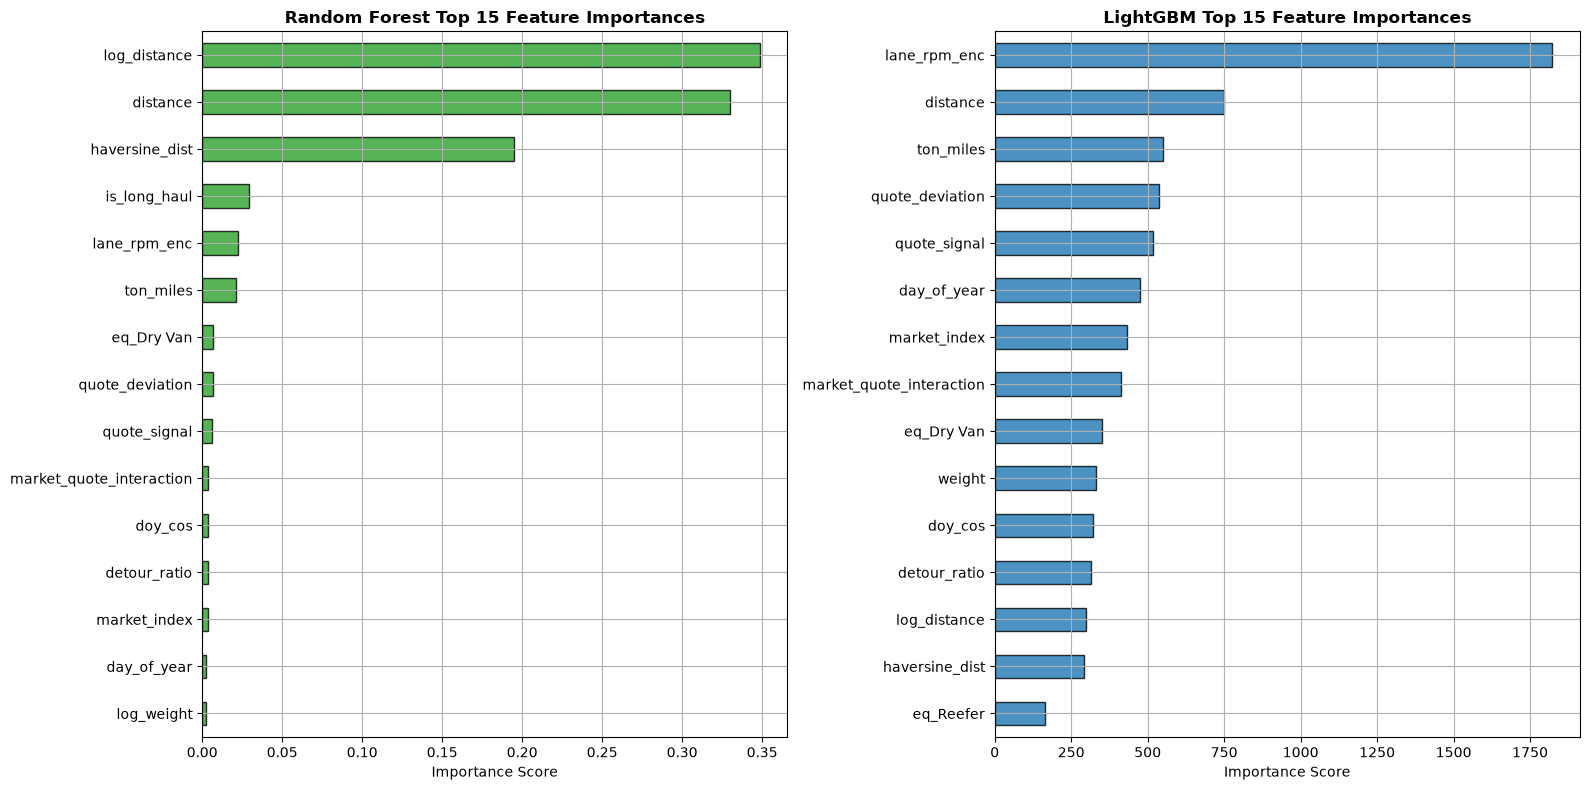


Top 5 Most Important Features in Random Forest:
log_distance     0.3484
distance         0.3300
haversine_dist   0.1951
is_long_haul     0.0292
lane_rpm_enc     0.0222
dtype: float64


In [13]:
# Cell 9: Feature Importance Plot (Champion Random Forest & LightGBM)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest Feature Importance (MDI)
rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
rf_imp.tail(15).plot(kind="barh", ax=axes[0], color="#2ca02c", edgecolor="black", alpha=0.8)
axes[0].set_title("Random Forest Top 15 Feature Importances", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importance Score")

# LightGBM Feature Importance (Gain)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
lgb_imp.tail(15).plot(kind="barh", ax=axes[1], color="#1f77b4", edgecolor="black", alpha=0.8)
axes[1].set_title("LightGBM Top 15 Feature Importances", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features in Random Forest:")
print(rf_imp.sort_values(ascending=False).head(5))

In [14]:
# Cell 10: Retrain Champion Model on FULL Training Data (Jan-Oct 2025, 48,000 loads)
# Training on the full 10 months incorporates October dynamics before predicting Nov-Dec
X_full = train_df[FEATURE_COLS]
y_full = train_df[TARGET]

print(f"Retraining Champion Model ({champion_name}) on full 48,000 training loads...")

if champion_name == "Random Forest":
    champion_final = RandomForestRegressor(
        n_estimators=350,
        max_depth=16,
        min_samples_leaf=4,
        max_features=0.6,
        n_jobs=-1,
        random_state=SEED
    )
    champion_final.fit(X_full, y_full)
elif champion_name == "LightGBM":
    champion_final = lgb.LGBMRegressor(**{**lgb_params, "n_estimators": lgb_model.best_iteration_ + 50})
    champion_final.fit(X_full, y_full)
else:
    scaler_full = StandardScaler()
    X_full_sc = scaler_full.fit_transform(X_full)
    champion_final = Ridge(alpha=1.0)
    champion_final.fit(X_full_sc, y_full)

print("Champion model retrained successfully on full dataset!")

Retraining Champion Model (Random Forest) on full 48,000 training loads...
Champion model retrained successfully on full dataset!


In [15]:
# Cell 11: Generate Validation Predictions (Nov-Dec 2025, 12,000 rows)
X_val = val_df[FEATURE_COLS]
val_preds = champion_final.predict(X_val)
val_preds = np.clip(val_preds, 1.0, None)

# Load the template to match required format
def find_data_file(filename):
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(filename)

template = pd.read_csv(find_data_file("validation-predictions-template.csv"))
template["predicted_rate"] = np.round(val_preds, 2)

print(f"Validation predictions shape: {template.shape}")
print(f"Min predicted rate:  ${val_preds.min():.2f}")
print(f"Max predicted rate:  ${val_preds.max():.2f}")
print(f"Mean predicted rate: ${val_preds.mean():.2f}")
print(f"Any negatives or zeros: {(val_preds <= 0).sum()}")
display(template.head())

Validation predictions shape: (12000, 2)
Min predicted rate:  $191.78
Max predicted rate:  $7651.01
Mean predicted rate: $2440.95
Any negatives or zeros: 0


,load_id,predicted_rate
0,TE-000001,836.3800
1,TE-000002,4907.0400
2,TE-000003,6001.9600
3,TE-000004,4331.7800
4,TE-000005,1820.0000


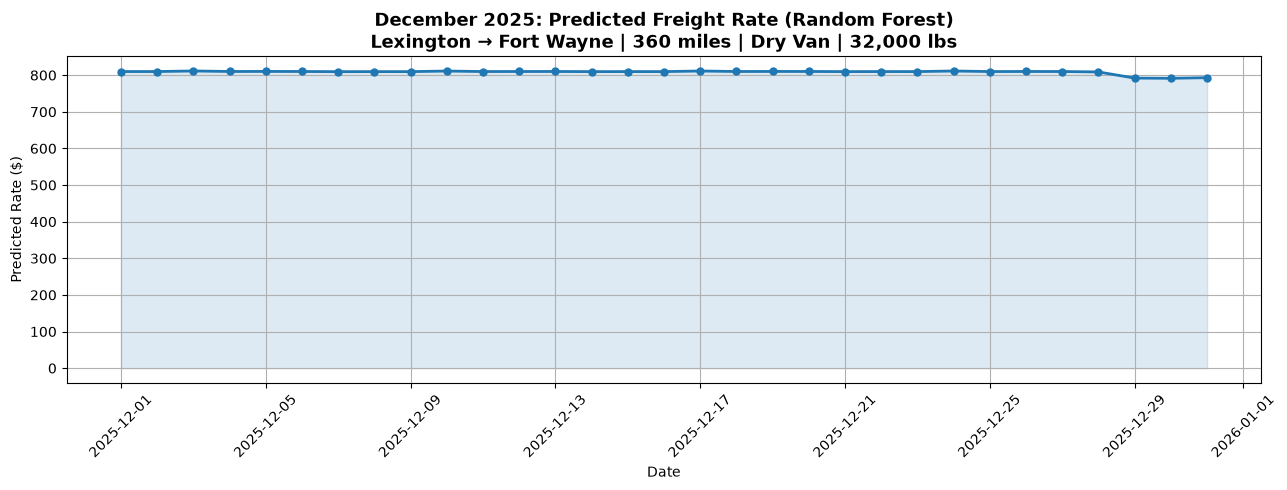

December predicted rates: Min=$791.57 | Max=$811.52 | Mean=$808.37


In [16]:
# Cell 12: Generate December Chart Predictions (31 days, Lexington -> Fort Wayne)
X_dec = dec_df[FEATURE_COLS]
dec_preds = champion_final.predict(X_dec)
dec_preds = np.clip(dec_preds, 1.0, None)

dec_df["predicted_rate"] = np.round(dec_preds, 2)

# Plot December Forecast
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dec_df["date"], dec_df["predicted_rate"], color="#1f77b4", marker="o", linewidth=2, markersize=5)
ax.fill_between(dec_df["date"], dec_df["predicted_rate"], alpha=0.15, color="#1f77b4")
ax.set_title(f"December 2025: Predicted Freight Rate ({champion_name})\nLexington → Fort Wayne | 360 miles | Dry Van | 32,000 lbs",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Predicted Rate ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"December predicted rates: Min=${dec_preds.min():.2f} | Max=${dec_preds.max():.2f} | Mean=${dec_preds.mean():.2f}")

In [17]:
# Cell 13: Save All Submission Artifacts
def find_root():
    if os.path.exists("data"):
        return "."
    elif os.path.exists(os.path.join("..", "data")):
        return ".."
    raise RuntimeError("Cannot find data root.")

ROOT = find_root()

# 1. Validation predictions CSV (matches score.py expected format)
val_out_path = os.path.join(ROOT, "data", "validation_predictions.csv")
template.to_csv(val_out_path, index=False)
print(f"Saved: {os.path.abspath(val_out_path)} ({len(template):,} rows)")

# 2. December chart inputs CSV (overwrites original with filled predicted_rate column)
dec_out_path = os.path.join(ROOT, "data", "december-chart-inputs.csv")
dec_df[["pickup", "delivery", "distance", "equipment" if "equipment" in dec_df.columns else "eq_Dry Van",
        "weight", "date", "predicted_rate"]].to_csv(dec_out_path, index=False)
print(f"Saved: {os.path.abspath(dec_out_path)} ({len(dec_df)} rows)")

Saved: d:\ml\data\validation_predictions.csv (12,000 rows)
Saved: d:\ml\data\december-chart-inputs.csv (31 rows)


In [18]:
# Cell 14: Sanity Check — All Predictions Positive (score.py requirement)
val_check = pd.read_csv(val_out_path)
dec_check = pd.read_csv(dec_out_path)

val_min = val_check["predicted_rate"].min()
dec_min = dec_check["predicted_rate"].min()

assert val_min > 0, f"ERROR: Validation has non-positive predictions! Min={val_min}"
assert dec_min > 0, f"ERROR: December has non-positive predictions! Min={dec_min}"

print("PASS: All validation predictions > 0")
print("PASS: All December predictions > 0")
print(f"  Validation: {len(val_check):,} rows | Min=${val_min:.2f} | Max=${val_check['predicted_rate'].max():.2f}")
print(f"  December:   {len(dec_check)} rows  | Min=${dec_min:.2f} | Max=${dec_check['predicted_rate'].max():.2f}")

PASS: All validation predictions > 0
PASS: All December predictions > 0
  Validation: 12,000 rows | Min=$191.78 | Max=$7651.01
  December:   31 rows  | Min=$791.57 | Max=$811.52


In [19]:
# Cell 15: Final Summary
print("=" * 60)
print("  FREIGHT RATE PREDICTION — MODELING COMPLETE")
print("=" * 60)
print()
print("MODEL BENCHMARK RESULTS (OOT Oct 2025 Holdout):")
display(comparison_df)
print()
print(f"CHAMPION MODEL: {champion_name}")
print()
print("ARTIFACTS SAVED:")
print(f"  - data/validation_predictions.csv  (12,000 rows)")
print(f"  - data/december-chart-inputs.csv   (31 rows, predicted_rate filled)")
print()
print("NEXT STEP: Run score.py to generate scorer_results/candidate_december.png")
print("=" * 60)

  FREIGHT RATE PREDICTION — MODELING COMPLETE

MODEL BENCHMARK RESULTS (OOT Oct 2025 Holdout):


,Model,MAE ($),RMSE ($),MAPE (%),R²
1,Random Forest,153.5268,672.7477,7.1023,0.8063
2,LightGBM,163.1837,677.5134,8.7106,0.8035
0,Ridge (Baseline),177.8272,662.9109,11.4172,0.8119



CHAMPION MODEL: Random Forest

ARTIFACTS SAVED:
  - data/validation_predictions.csv  (12,000 rows)
  - data/december-chart-inputs.csv   (31 rows, predicted_rate filled)

NEXT STEP: Run score.py to generate scorer_results/candidate_december.png


## Run Scorer
After saving artifacts, open a terminal in the project root and run:
```bash
python score.py
```
This will validate all 12,000 predictions and generate `scorer_results/candidate_december.png`.